# **`Lending Default Risk`**
### **Notebook: 01 – Data Science & Exploratory Data Analysis (EDA)**

**Objective:**  
This notebook focuses on understanding, cleaning, transforming, and visualizing the credit risk dataset to prepare it for downstream Machine Learning tasks

**Key Tasks:**

- Load dataset  
- Inspect structure  
- Clean missing/invalid values  
- Correct datatypes  
- Remove outliers  
- Explore sales trends  
- Export cleaned dataset

### **`IMPORTING REQUIRED LIBRARIES`**

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

from prettytable import PrettyTable
from IPython.display import display, Markdown

In [29]:
from scipy.stats import (
    skew, kurtosis, shapiro, kstest, normaltest,
    chi2_contingency, f_oneway, pearsonr, spearmanr
)
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer

### **`LOADING THE DATASET`**

In [2]:
file_path = r"C:\Users\tejas\OneDrive\Desktop\CPMLF Capstone Projects\CREDIT CARD RISK\data\raw\loan_data_preprocessed.csv"

In [3]:
df = pd.read_csv(file_path)

In [4]:
df

,Unnamed: 0.1,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,...,addr_state:UT,addr_state:VA,addr_state:VT,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,initial_list_status:f,initial_list_status:w,good_bad
0,0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,...,0,0,0,0,0,0,0,1,0,1
1,1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,...,0,0,0,0,0,0,0,1,0,0
2,2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,...,0,0,0,0,0,0,0,1,0,1
3,3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,...,0,0,0,0,0,0,0,1,0,1
4,4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,...,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,466280,466280,8598660,1440975,18400,18400,18400.0,60 months,14.47,432.64,...,0,0,0,0,0,0,0,0,1,1
466281,466281,466281,9684700,11536848,22000,22000,22000.0,60 months,19.97,582.50,...,0,0,0,0,0,0,0,1,0,0
466282,466282,466282,9584776,11436914,20700,20700,20700.0,60 months,16.99,514.34,...,0,0,0,0,0,0,0,1,0,1
466283,466283,466283,9604874,11457002,2000,2000,2000.0,36 months,7.90,62.59,...,0,0,0,0,0,0,0,0,1,1


### **`QUICK INSPECTION`**

In [5]:
print("First 5 rows: ", df.head())

First 5 rows:     Unnamed: 0.1  Unnamed: 0       id  member_id  loan_amnt  funded_amnt  \
0             0           0  1077501    1296599       5000         5000   
1             1           1  1077430    1314167       2500         2500   
2             2           2  1077175    1313524       2400         2400   
3             3           3  1076863    1277178      10000        10000   
4             4           4  1075358    1311748       3000         3000   

   funded_amnt_inv        term  int_rate  installment  ... addr_state:UT  \
0           4975.0   36 months     10.65       162.87  ...             0   
1           2500.0   60 months     15.27        59.83  ...             0   
2           2400.0   36 months     15.96        84.33  ...             0   
3          10000.0   36 months     13.49       339.31  ...             0   
4           3000.0   60 months     12.69        67.79  ...             0   

  addr_state:VA addr_state:VT addr_state:WA addr_state:WI  addr_state:WV  \
0

In [6]:
print("Last 5 rows:", df.tail())

Last 5 rows:         Unnamed: 0.1  Unnamed: 0       id  member_id  loan_amnt  funded_amnt  \
466280        466280      466280  8598660    1440975      18400        18400   
466281        466281      466281  9684700   11536848      22000        22000   
466282        466282      466282  9584776   11436914      20700        20700   
466283        466283      466283  9604874   11457002       2000         2000   
466284        466284      466284  9199665   11061576      10000        10000   

        funded_amnt_inv        term  int_rate  installment  ... addr_state:UT  \
466280          18400.0   60 months     14.47       432.64  ...             0   
466281          22000.0   60 months     19.97       582.50  ...             0   
466282          20700.0   60 months     16.99       514.34  ...             0   
466283           2000.0   36 months      7.90        62.59  ...             0   
466284           9975.0   36 months     19.20       367.58  ...             0   

       addr_state:V

In [7]:
df.select_dtypes(include=[np.number]).head(5)

,Unnamed: 0.1,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,...,addr_state:UT,addr_state:VA,addr_state:VT,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,initial_list_status:f,initial_list_status:w,good_bad
0,0,0,1077501,1296599,5000,5000,4975.0,10.65,162.87,24000.0,...,0,0,0,0,0,0,0,1,0,1
1,1,1,1077430,1314167,2500,2500,2500.0,15.27,59.83,30000.0,...,0,0,0,0,0,0,0,1,0,0
2,2,2,1077175,1313524,2400,2400,2400.0,15.96,84.33,12252.0,...,0,0,0,0,0,0,0,1,0,1
3,3,3,1076863,1277178,10000,10000,10000.0,13.49,339.31,49200.0,...,0,0,0,0,0,0,0,1,0,1
4,4,4,1075358,1311748,3000,3000,3000.0,12.69,67.79,80000.0,...,0,0,0,0,0,0,0,1,0,1


In [8]:
df.select_dtypes(include="object").tail(5)

,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,issue_d,loan_status,pymnt_plan,...,zip_code,addr_state,earliest_cr_line,initial_list_status,last_pymnt_d,next_pymnt_d,last_credit_pull_d,application_type,earliest_cr_line_date,issue_d_date
466280,60 months,C,C2,Financial Advisor,4 years,MORTGAGE,Source Verified,Jan-14,Current,n,...,773xx,TX,Apr-03,w,Jan-16,Feb-16,Jan-16,INDIVIDUAL,2003-04-01,2014-01-01
466281,60 months,D,D5,Chief of Interpretation (Park Ranger),10+ years,MORTGAGE,Verified,Jan-14,Charged Off,n,...,377xx,TN,Jun-97,f,Dec-14,NaN,Jan-16,INDIVIDUAL,1997-06-01,2014-01-01
466282,60 months,D,D1,patrol,7 years,MORTGAGE,Verified,Jan-14,Current,n,...,458xx,OH,Dec-01,f,Jan-16,Feb-16,Dec-15,INDIVIDUAL,2001-12-01,2014-01-01
466283,36 months,A,A4,Server Engineer Lead,3 years,OWN,Verified,Jan-14,Fully Paid,n,...,913xx,CA,Feb-03,w,Dec-14,NaN,Apr-15,INDIVIDUAL,2003-02-01,2014-01-01
466284,36 months,D,D3,NaN,10+ years,MORTGAGE,Verified,Jan-14,Current,n,...,950xx,CA,Feb-00,f,Jan-16,Feb-16,Jan-16,INDIVIDUAL,2000-02-01,2014-01-01


In [9]:
print("\n|------------------------------------------------------ DESCRIPTIVE STATS -----------------------------------------------------|")
df.describe(
    include='all'
).T


|------------------------------------------------------ DESCRIPTIVE STATS -----------------------------------------------------|


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0.1,466285.0,NaN,NaN,NaN,233142.0,134605.029472,0.0,116571.0,233142.0,349713.0,466284.0
Unnamed: 0,466285.0,NaN,NaN,NaN,233142.0,134605.029472,0.0,116571.0,233142.0,349713.0,466284.0
id,466285.0,NaN,NaN,NaN,13079729.906182,10893711.624551,54734.0,3639987.0,10107897.0,20731209.0,38098114.0
member_id,466285.0,NaN,NaN,NaN,14597660.622827,11682367.44145,70473.0,4379705.0,11941075.0,23001541.0,40860827.0
loan_amnt,466285.0,NaN,NaN,NaN,14317.277577,8286.509164,500.0,8000.0,12000.0,20000.0,35000.0
...,...,...,...,...,...,...,...,...,...,...,...
addr_state:WV,466285.0,NaN,NaN,NaN,0.005173,0.071736,0.0,0.0,0.0,0.0,1.0
addr_state:WY,466285.0,NaN,NaN,NaN,0.002419,0.049125,0.0,0.0,0.0,0.0,1.0
initial_list_status:f,466285.0,NaN,NaN,NaN,0.649828,0.477024,0.0,0.0,1.0,1.0,1.0
initial_list_status:w,466285.0,NaN,NaN,NaN,0.350172,0.477024,0.0,0.0,0.0,1.0,1.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Columns: 209 entries, Unnamed: 0.1 to good_bad
dtypes: float64(49), int64(136), object(24)
memory usage: 743.5+ MB


In [12]:
print("\n|------------------------------------------------------ DESCRIBE -----------------------------------------------------|")
df.describe(include='all')


|------------------------------------------------------ DESCRIBE -----------------------------------------------------|


,Unnamed: 0.1,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,...,addr_state:UT,addr_state:VA,addr_state:VT,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,initial_list_status:f,initial_list_status:w,good_bad
count,466285.000000,466285.000000,4.662850e+05,4.662850e+05,466285.000000,466285.000000,466285.000000,466285,466285.000000,466285.000000,...,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36 months,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,337953,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,233142.000000,233142.000000,1.307973e+07,1.459766e+07,14317.277577,14291.801044,14222.329888,NaN,13.829236,432.061201,...,0.007352,0.030501,0.001941,0.022555,0.012677,0.005173,0.002419,0.649828,0.350172,0.890693
std,134605.029472,134605.029472,1.089371e+07,1.168237e+07,8286.509164,8274.371300,8297.637788,NaN,4.357587,243.485550,...,0.085427,0.171961,0.044013,0.148480,0.111875,0.071736,0.049125,0.477024,0.477024,0.312024
min,0.000000,0.000000,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,NaN,5.420000,15.670000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,116571.000000,116571.000000,3.639987e+06,4.379705e+06,8000.000000,8000.000000,8000.000000,NaN,10.990000,256.690000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,233142.000000,233142.000000,1.010790e+07,1.194108e+07,12000.000000,12000.000000,12000.000000,NaN,13.660000,379.890000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,349713.000000,349713.000000,2.073121e+07,2.300154e+07,20000.000000,20000.000000,19950.000000,NaN,16.490000,566.580000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000


In [13]:
df.shape

(466285, 209)

**CHECKING DATASET SUMMARY**

In [14]:
table = PrettyTable()
table.field_names = ["Metric", "Value"]

table.add_row(["Total Rows", df.shape[0]])
table.add_row(["Total Columns", df.shape[1]])
table.add_row(["Duplicate Rows", df.duplicated().sum()])
table.add_row(["Columns with Nulls", df.isnull().any().sum()])

table.align = "l"

print(table)

+--------------------+--------+
| Metric             | Value  |
+--------------------+--------+
| Total Rows         | 466285 |
| Total Columns      | 209    |
| Duplicate Rows     | 0      |
| Columns with Nulls | 33     |
+--------------------+--------+


**Checking for Data Types Summary**

In [51]:
dtype_counts = df.dtypes.value_counts()

dtype_table = PrettyTable()
dtype_table.field_names = ["Data Type", "Count"]

# Add rows
for dtype, count in dtype_counts.items():
    dtype_table.add_row([str(dtype), count])

# Left align the text
dtype_table.align = "l"

print("\nData Types Summary:")
# print("="*30)
print(dtype_table)


Data Types Summary:
+-----------+-------+
| Data Type | Count |
+-----------+-------+
| int64     | 136   |
| float64   | 49    |
| object    | 24    |
+-----------+-------+


In [15]:
table = PrettyTable()
table.field_names = ["Column", "Data Type", "Missing", "Missing %", "Unique"]

for col in df.columns:
    dtype = df[col].dtype
    missing = df[col].isnull().sum()
    missing_pct = round((missing / len(df)) * 100, 2)
    unique = df[col].nunique()
    table.add_row([col, str(dtype), missing, f"{missing_pct}%", unique])

table.align = "l"

print("DataFrame Information Summary")
# print("="*35)
print(table)

DataFrame Information Summary
+-----------------------------------------------------------------+-----------+---------+-----------+--------+
| Column                                                          | Data Type | Missing | Missing % | Unique |
+-----------------------------------------------------------------+-----------+---------+-----------+--------+
| Unnamed: 0.1                                                    | int64     | 0       | 0.0%      | 466285 |
| Unnamed: 0                                                      | int64     | 0       | 0.0%      | 466285 |
| id                                                              | int64     | 0       | 0.0%      | 466285 |
| member_id                                                       | int64     | 0       | 0.0%      | 466285 |
| loan_amnt                                                       | int64     | 0       | 0.0%      | 1352   |
| funded_amnt                                                     | int64     | 0 

In [16]:
unique_cols = [col for col in df.columns if df[col].nunique() == df.shape[0]]

print("Most Possible Unique ID Columns:")
for col in unique_cols:
    print("-", col)

Most Possible Unique ID Columns:
- Unnamed: 0.1
- Unnamed: 0
- id
- member_id
- url


In [17]:
unclean_table = PrettyTable()
unclean_table.field_names = ["Column Name", "Issue"]


for col in df.columns:
    issues = []
    if ' ' in col:
        issues.append("Contains space")
    if not col.isidentifier():
        issues.append("Invalid identifier")
    
    if issues:
        unclean_table.add_row([col, ', '.join(issues)])

# Aligning the text to the Left hand side
unclean_table.align = "l"


if unclean_table.rowcount > 0:
    print("Unclean Column Name Report: ")
    print("-" * 105)
    print(unclean_table)
else:
    print("All column Names are clean!!!")

Unclean Column Name Report: 
---------------------------------------------------------------------------------------------------------
+-----------------------------------------------------------------+------------------------------------+
| Column Name                                                     | Issue                              |
+-----------------------------------------------------------------+------------------------------------+
| Unnamed: 0.1                                                    | Contains space, Invalid identifier |
| Unnamed: 0                                                      | Contains space, Invalid identifier |
| grade:A                                                         | Invalid identifier                 |
| grade:B                                                         | Invalid identifier                 |
| grade:C                                                         | Invalid identifier                 |
| grade:D                

In [18]:
total_cells = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
missing_percent = (total_missing / total_cells) * 100

print(f"Overall Missing Data: {total_missing} values missing out of {total_cells} cells")
print(f"Total Missing Percentage: {missing_percent:.2f}%")

Overall Missing Data: 9705802 values missing out of 97453565 cells
Total Missing Percentage: 9.96%


### ***Cardinality Check for Categorical data***

In [27]:
cat_cols = df.select_dtypes(exclude=np.number).columns

for c in cat_cols:
    print(f"{c}: Unique - {df[c].nunique()}")

term: Unique - 2
grade: Unique - 7
sub_grade: Unique - 35
emp_title: Unique - 205476
emp_length: Unique - 12
home_ownership: Unique - 6
verification_status: Unique - 3
issue_d: Unique - 91
loan_status: Unique - 9
pymnt_plan: Unique - 2
url: Unique - 466285
desc: Unique - 124435
purpose: Unique - 14
title: Unique - 63098
zip_code: Unique - 888
addr_state: Unique - 50
earliest_cr_line: Unique - 665
initial_list_status: Unique - 2
last_pymnt_d: Unique - 99
next_pymnt_d: Unique - 101
last_credit_pull_d: Unique - 104
application_type: Unique - 1
earliest_cr_line_date: Unique - 665
issue_d_date: Unique - 91


### ***Column Sematics Validation***

In [54]:
for col in df.columns:
    print(col, "->", df[col].dtype)


Unnamed: 0.1 -> int64
Unnamed: 0 -> int64
id -> int64
member_id -> int64
loan_amnt -> int64
funded_amnt -> int64
funded_amnt_inv -> float64
term -> object
int_rate -> float64
installment -> float64
grade -> object
sub_grade -> object
emp_title -> object
emp_length -> object
home_ownership -> object
annual_inc -> float64
verification_status -> object
issue_d -> object
loan_status -> object
pymnt_plan -> object
url -> object
desc -> object
purpose -> object
title -> object
zip_code -> object
addr_state -> object
dti -> float64
delinq_2yrs -> float64
earliest_cr_line -> object
inq_last_6mths -> float64
mths_since_last_delinq -> float64
mths_since_last_record -> float64
open_acc -> float64
pub_rec -> float64
revol_bal -> int64
revol_util -> float64
total_acc -> float64
initial_list_status -> object
out_prncp -> float64
out_prncp_inv -> float64
total_pymnt -> float64
total_pymnt_inv -> float64
total_rec_prncp -> float64
total_rec_int -> float64
total_rec_late_fee -> float64
recoveries -> fl

### ***Duplicate Records Analysis***

In [58]:
dup_rows = df.duplicated().sum()
dup_rows

0

***Logical duplicates (If same customer, multiple loans?)***

In [60]:
df.duplicated(subset=["member_id"], keep=False).sum()

0

### ***Numerical Distribution Summary:***

In [30]:
num_cols = df.select_dtypes(include=np.number).columns

dist_summary = pd.DataFrame({
    "mean": df[num_cols].mean(),
    "median": df[num_cols].median(),
    "std": df[num_cols].std(),
    "min": df[num_cols].min(),
    "max": df[num_cols].max(),
    "skewness": df[num_cols].apply(skew),
    "kurtosis": df[num_cols].apply(kurtosis)
})

dist_summary

,mean,median,std,min,max,skewness,kurtosis
Unnamed:_0.1,2.331420e+05,233142.0,1.346050e+05,0.0,466284.0,-1.728890e-15,-1.200000
Unnamed:_0,2.331420e+05,233142.0,1.346050e+05,0.0,466284.0,-1.728890e-15,-1.200000
id,1.307973e+07,10107897.0,1.089371e+07,54734.0,38098114.0,6.924537e-01,-0.727664
member_id,1.459766e+07,11941075.0,1.168237e+07,70473.0,40860827.0,6.213915e-01,-0.797488
loan_amnt,1.431728e+04,12000.0,8.286509e+03,500.0,35000.0,7.309775e-01,-0.134890
...,...,...,...,...,...,...,...
addr_state:WV,5.172802e-03,0.0,7.173601e-02,0.0,1.0,1.379580e+01,188.324022
addr_state:WY,2.419121e-03,0.0,4.912509e-02,0.0,1.0,2.025773e+01,408.375652
initial_list_status:f,6.498279e-01,1.0,4.770242e-01,0.0,1.0,-6.281780e-01,-1.605392
initial_list_status:w,3.501721e-01,0.0,4.770242e-01,0.0,1.0,6.281780e-01,-1.605392


**CHECKING FOR OUTLIERS**

<Axes: >

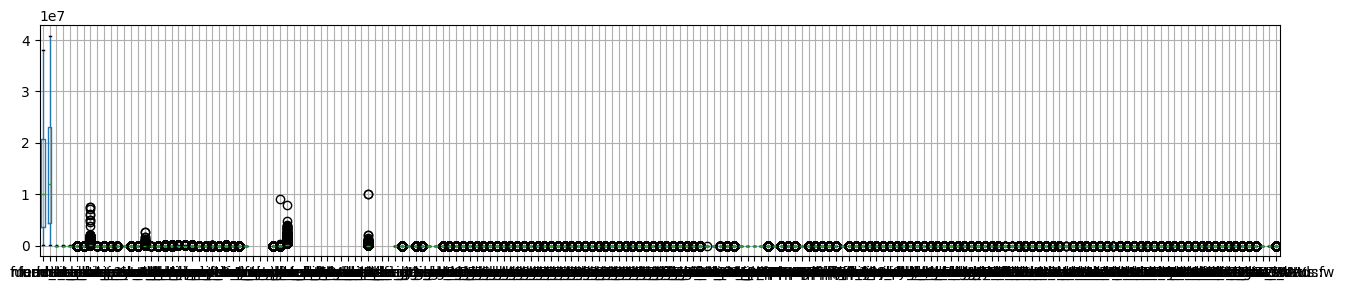

In [85]:
plt.figure(figsize=(16, 3))
df.boxplot()

## **DATA CLEANING**

## ***Cleaning Column Names (If Any)***

In [20]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

print("- Column names standardized.")
df.columns

- Column names standardized.


Index(['Unnamed:_0.1', 'Unnamed:_0', 'id', 'member_id', 'loan_amnt',
       'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment',
       ...
       'addr_state:UT', 'addr_state:VA', 'addr_state:VT', 'addr_state:WA',
       'addr_state:WI', 'addr_state:WV', 'addr_state:WY',
       'initial_list_status:f', 'initial_list_status:w', 'good_bad'],
      dtype='object', length=209)

In [71]:
cols_to_drop = ['Unnamed:_0.1', 'Unnamed:_0']
df.drop(columns=[col for col in cols_to_drop if col in df.columns],
        inplace=True)

In [72]:
df.head()

,Unnamed: 0.1,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int,earliest_cr_line_date,mths_since_earliest_cr_line,term_int,issue_d_date,mths_since_issue_d,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,sub_grade:A1,sub_grade:A2,sub_grade:A3,sub_grade:A4,sub_grade:A5,sub_grade:B1,sub_grade:B2,sub_grade:B3,sub_grade:B4,sub_grade:B5,sub_grade:C1,sub_grade:C2,sub_grade:C3,sub_grade:C4,sub_grade:C5,sub_grade:D1,sub_grade:D2,sub_grade:D3,sub_grade:D4,sub_grade:D5,sub_grade:E1,sub_grade:E2,sub_grade:E3,sub_grade:E4,sub_grade:E5,sub_grade:F1,sub_grade:F2,sub_grade:F3,sub_grade:F4,sub_grade:F5,sub_grade:G1,sub_grade:G2,sub_grade:G3,sub_grade:G4,sub_grade:G5,home_ownership:ANY,home_ownership:MORTGAGE,home_ownership:NONE,home_ownership:OTHER,home_ownership:OWN,home_ownership:RENT,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,loan_status:Charged Off,loan_status:Current,loan_status:Default,loan_status:Does not meet the credit policy. Status:Charged Off,loan_status:Does not meet the credit policy. Status:Fully Paid,loan_status:Fully Paid,loan_status:In Grace Period,loan_status:Late (16-30 days),loan_status:Late (31-120 days),purpose:car,purpose:credit_card,purpose:debt_consolidation,purpose:educational,purpose:home_improvement,purpose:house,purpose:major_purchase,purpose:medical,purpose:moving,purpose:other,purpose:renewable_energy,purpose:small_business,purpose:vacation,purpose:wedding,addr_state:AK,addr_state:AL,addr_state:AR,addr_state:AZ,addr_state:CA,addr_state:CO,addr_state:CT,addr_state:DC,addr_state:DE,addr_state:FL,addr_state:GA,addr_state:HI,addr_state:IA,addr_state:ID,addr_state:IL,addr_state:IN,addr_state:KS,addr_state:KY,addr_state:LA,addr_state:MA,addr_state:MD,addr_state:ME,addr_state:MI,addr_state:MN,addr_state:MO,addr_state:MS,addr_state:MT,addr_state:NC,addr_state:NE,addr_state:NH,addr_state:NJ,addr_state:NM,addr_state:NV,addr_state:NY,addr_state:OH,addr_state:OK,addr_state:OR,addr_state:PA,addr_state:RI,addr_state:SC,addr_state:SD,addr_state:TN,addr_state:TX,addr_state:UT,addr_state:VA,addr_state:VT,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,initial_list_status:f,initial_list_status:w,good_bad
0,0,0,1077501,1296599,5000,5000,4975.0000,36 months,10.6500,162.8700,B,B2,NaN,10+ years,RENT,24000.0000,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.6500,0.0000,Jan-85,1.0000,NaN,NaN,3.0000,0.0000,13648,83.7000,9.0000,f,0.0000,0.0000,5861.0714,5831.7800,5000.0000,861.0700,0.0000,0.0000,0.0000,Jan-15,171.6200,NaN,Jan-16,0.0000,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000.0000,NaN,NaN,NaN,10.0000,1985-01-01,395.0000,36,2011-12-01,72.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
1,1,1,1

## ***Handling Missing Values***

In [74]:
missing = df.isnull().sum()
total_rows = df.shape[0]

missing_filtered = missing[missing > 0]
missing_percent = (missing_filtered / total_rows) * 100
filtered = missing_percent[missing_percent < 100].sort_values(ascending=False)

miss_table = PrettyTable()
miss_table.field_names = ["Column", "Missing Values", "Missing %"]

for col in filtered.index:
    miss_val = missing[col]
    miss_pct = filtered[col]
    miss_table.add_row([col, miss_val, f"{miss_pct:.2f}%"])

miss_table.align = "l"

print("|--------Missing Values Summary [Below 100% Only]---------|")
print(miss_table)

|--------Missing Values Summary [Below 100% Only]---------|
+-----------------------------+----------------+-----------+
| Column                      | Missing Values | Missing % |
+-----------------------------+----------------+-----------+
| mths_since_last_record      | 403647         | 86.57%    |
| mths_since_last_major_derog | 367311         | 78.77%    |
| desc                        | 340304         | 72.98%    |
| mths_since_last_delinq      | 250351         | 53.69%    |
| next_pymnt_d                | 227214         | 48.73%    |
| tot_coll_amt                | 70276          | 15.07%    |
| tot_cur_bal                 | 70276          | 15.07%    |
| emp_title                   | 27588          | 5.92%     |
| emp_length                  | 21008          | 4.51%     |
| last_pymnt_d                | 376            | 0.08%     |
| revol_util                  | 340            | 0.07%     |
| collections_12_mths_ex_med  | 145            | 0.03%     |
| last_credit_pull_d     

In [47]:
df_cleaned = df.copy()

### ***Numeric data***

In [76]:
for col in df_cleaned.select_dtypes(include=np.number).columns:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce') 
        median_val = df_cleaned[col].median()
        if np.isnan(median_val):   
            df_cleaned[col] = df_cleaned[col].fillna(0)  
            print(f"'{col}' had all NaNs filled with 0")
        else:
            df_cleaned[col] = df_cleaned[col].fillna(median_val)  

'annual_inc_joint' had all NaNs filled with 0
'dti_joint' had all NaNs filled with 0
'verification_status_joint' had all NaNs filled with 0
'open_acc_6m' had all NaNs filled with 0
'open_il_6m' had all NaNs filled with 0
'open_il_12m' had all NaNs filled with 0
'open_il_24m' had all NaNs filled with 0
'mths_since_rcnt_il' had all NaNs filled with 0
'total_bal_il' had all NaNs filled with 0
'il_util' had all NaNs filled with 0
'open_rv_12m' had all NaNs filled with 0
'open_rv_24m' had all NaNs filled with 0
'max_bal_bc' had all NaNs filled with 0
'all_util' had all NaNs filled with 0
'inq_fi' had all NaNs filled with 0
'total_cu_tl' had all NaNs filled with 0
'inq_last_12m' had all NaNs filled with 0


### ***Categorical data***

In [77]:
for col in df_cleaned.select_dtypes(include="object").columns:
    if df_cleaned[col].isnull().sum() > 0:
        missing_ratio = df_cleaned[col].isnull().mean()

        if missing_ratio > 0.5:  
            print(f"Dropping '{col}' because {missing_ratio:.2%} missing")
            df_cleaned.drop(columns=[col], inplace=True)
        else:
            mode_val = df_cleaned[col].mode()[0] if not df_cleaned[col].mode().empty else "Unknown"
            df_cleaned[col] = df_cleaned[col].fillna(mode_val)
            print(f"Filled '{col}' missing values with mode {mode_val}")
    

In [80]:
missing = df_cleaned.isnull().sum().sort_values(ascending=False)

miss_table = PrettyTable()
miss_table.field_names = ["Columns", "Missing Values", "Missing %"]
miss_table.align = "l"
total_rows = df_cleaned.shape[0]   

for col, val in missing.items():
    percent = (val / total_rows) * 100
    miss_table.add_row([col, val, f"{percent:.2f}%"])

print("\nMissing Values Summary [After Cleaning]: ")
print(miss_table)

key_observ = """
**Key Observations:**

- All columns have **0%** missing values after cleaning, indicating a complete dataset,
no further imputation or handling of missing values is required.
- This ensures that all features are ready for modeling without any risk of data loss or bias due to missing values.
"""

display(Markdown(key_observ))


Missing Values Summary [After Cleaning]: 
+-----------------------------------------------------------------+----------------+-----------+
| Columns                                                         | Missing Values | Missing % |
+-----------------------------------------------------------------+----------------+-----------+
| Unnamed:_0.1                                                    | 0              | 0.00%     |
| sub_grade:D2                                                    | 0              | 0.00%     |
| loan_status:Charged_Off                                         | 0              | 0.00%     |
| loan_status:Current                                             | 0              | 0.00%     |
| loan_status:Default                                             | 0              | 0.00%     |
| loan_status:Does_not_meet_the_credit_policy._Status:Charged_Off | 0              | 0.00%     |
| loan_status:Does_not_meet_the_credit_policy._Status:Fully_Paid  | 0              |


**Key Observations:**

- All columns have **0%** missing values after cleaning, indicating a complete dataset,
no further imputation or handling of missing values is required.
- This ensures that all features are ready for modeling without any risk of data loss or bias due to missing values.


In [75]:
total_cells = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
missing_percent = (total_missing / total_cells) * 100

print(f"Overall Missing Data: {total_missing} values missing out of {total_cells} cells")
print(f"Total Missing Percentage: {missing_percent:.2f}%")

Overall Missing Data: 9705802 values missing out of 97453565 cells
Total Missing Percentage: 9.96%


### ***Handled Identified Issues in the Columns***

In [33]:
unclean_table = PrettyTable()
unclean_table.field_names = ["Column Name", "Issue"]


for col in df.columns:
    issues = []
    if ' ' in col:
        issues.append("Contains space")
    if not col.isidentifier():
        issues.append("No Issues Identified")
    
    if issues:
        unclean_table.add_row([col, ', '.join(issues)])

# Aligning the text to the Left hand side
unclean_table.align = "l"


if unclean_table.rowcount > 0:
    print("Unclean Column Name Report: ")
    print("-" * 105)
    print(unclean_table)
else:
    print("All column Names are clean!!!")

Unclean Column Name Report: 
---------------------------------------------------------------------------------------------------------
+-----------------------------------------------------------------+----------------------+
| Column Name                                                     | Issue                |
+-----------------------------------------------------------------+----------------------+
| Unnamed:_0.1                                                    | No Issues Identified |
| Unnamed:_0                                                      | No Issues Identified |
| grade:A                                                         | No Issues Identified |
| grade:B                                                         | No Issues Identified |
| grade:C                                                         | No Issues Identified |
| grade:D                                                         | No Issues Identified |
| grade:E                                     

### ***Dropping Unwanted Columns***

In [83]:
cols_to_drop = ["Unnamed: 0.1", "Unnamed: 0"]

df.drop(columns=[col for col in cols_to_drop if col in df.columns],
        inplace=True)

In [84]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int,earliest_cr_line_date,mths_since_earliest_cr_line,term_int,issue_d_date,mths_since_issue_d,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,sub_grade:A1,sub_grade:A2,sub_grade:A3,sub_grade:A4,sub_grade:A5,sub_grade:B1,sub_grade:B2,sub_grade:B3,sub_grade:B4,sub_grade:B5,sub_grade:C1,sub_grade:C2,sub_grade:C3,sub_grade:C4,sub_grade:C5,sub_grade:D1,sub_grade:D2,sub_grade:D3,sub_grade:D4,sub_grade:D5,sub_grade:E1,sub_grade:E2,sub_grade:E3,sub_grade:E4,sub_grade:E5,sub_grade:F1,sub_grade:F2,sub_grade:F3,sub_grade:F4,sub_grade:F5,sub_grade:G1,sub_grade:G2,sub_grade:G3,sub_grade:G4,sub_grade:G5,home_ownership:ANY,home_ownership:MORTGAGE,home_ownership:NONE,home_ownership:OTHER,home_ownership:OWN,home_ownership:RENT,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,loan_status:Charged Off,loan_status:Current,loan_status:Default,loan_status:Does not meet the credit policy. Status:Charged Off,loan_status:Does not meet the credit policy. Status:Fully Paid,loan_status:Fully Paid,loan_status:In Grace Period,loan_status:Late (16-30 days),loan_status:Late (31-120 days),purpose:car,purpose:credit_card,purpose:debt_consolidation,purpose:educational,purpose:home_improvement,purpose:house,purpose:major_purchase,purpose:medical,purpose:moving,purpose:other,purpose:renewable_energy,purpose:small_business,purpose:vacation,purpose:wedding,addr_state:AK,addr_state:AL,addr_state:AR,addr_state:AZ,addr_state:CA,addr_state:CO,addr_state:CT,addr_state:DC,addr_state:DE,addr_state:FL,addr_state:GA,addr_state:HI,addr_state:IA,addr_state:ID,addr_state:IL,addr_state:IN,addr_state:KS,addr_state:KY,addr_state:LA,addr_state:MA,addr_state:MD,addr_state:ME,addr_state:MI,addr_state:MN,addr_state:MO,addr_state:MS,addr_state:MT,addr_state:NC,addr_state:NE,addr_state:NH,addr_state:NJ,addr_state:NM,addr_state:NV,addr_state:NY,addr_state:OH,addr_state:OK,addr_state:OR,addr_state:PA,addr_state:RI,addr_state:SC,addr_state:SD,addr_state:TN,addr_state:TX,addr_state:UT,addr_state:VA,addr_state:VT,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,initial_list_status:f,initial_list_status:w,good_bad
0,1077501,1296599,5000,5000,4975.0000,36 months,10.6500,162.8700,B,B2,NaN,10+ years,RENT,24000.0000,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.6500,0.0000,Jan-85,1.0000,NaN,NaN,3.0000,0.0000,13648,83.7000,9.0000,f,0.0000,0.0000,5861.0714,5831.7800,5000.0000,861.0700,0.0000,0.0000,0.0000,Jan-15,171.6200,NaN,Jan-16,0.0000,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000.0000,NaN,NaN,NaN,10.0000,1985-01-01,395.0000,36,2011-12-01,72.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
1,1077430,1314167,2500,2500,2500.00

## ***Checking for Outliers***

### ***7.1 Check before handling***

In [35]:
df_cleaned = df.copy()

<Axes: >

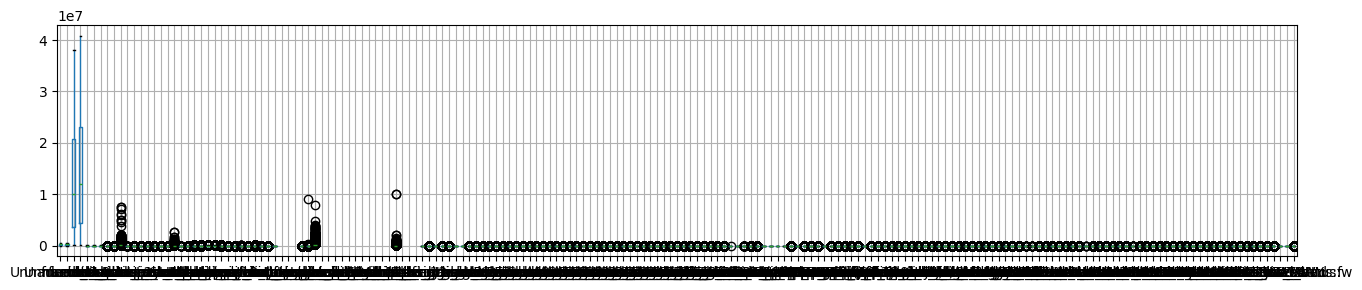

In [36]:
plt.figure(figsize=(16, 3))
df.boxplot()

### ***7.2 Handling Outliers using IQR Method***

In [37]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

def remove_outlier(col):
    sorted(col)
    Q1,Q3=np.percentile(col,[25,75])
    IQR=Q3-Q1
    lower_range= Q1-(1.5 * IQR)
    upper_range= Q3+(1.5 * IQR)
    return lower_range, upper_range

In [38]:
for column in df_cleaned.columns:
    if df_cleaned[column].dtype != 'object': 
        lr,ur=remove_outlier(df_cleaned[column])
        df_cleaned[column]=np.where(df_cleaned[column]>ur,ur,df_cleaned[column])
        df_cleaned[column]=np.where(df_cleaned[column]<lr,lr,df_cleaned[column])

### ***7.3 Checking after handling outliers***

<Axes: >

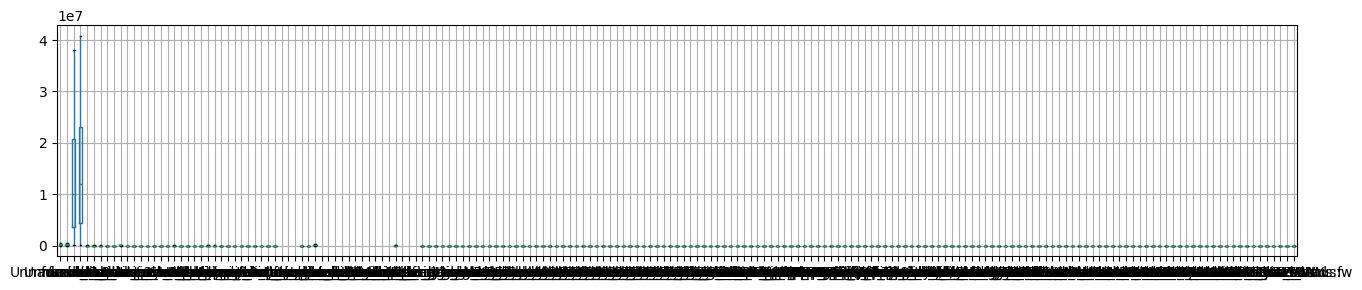

In [39]:
plt.figure(figsize=(16, 3))
df_cleaned.boxplot()

## ***Domain Rule Cleaning***

In [95]:
df_domain = df.copy()

In [96]:
target_col = "good_bad"

### ***1. LOAN TERM + EMPLOYMENT SANITY***

***Loan term must be valid product***

In [98]:
df_domain = df_domain[df_domain["term_int"].isin([36, 60])]

***Employment length realism***

In [99]:
df_domain = df_domain[df_domain["emp_length_int"].between(0, 50)]

### ***2. EMI vs INCOME - CORE CREDIT RULE***

In [100]:
monthly_income = df_domain["annual_inc"] / 12
df_domain = df_domain[df_domain["installment"] <= monthly_income]

***Industry-safe DTI cap (50%)***

In [101]:
MAX_DTI = 0.5
df_domain = df_domain[df_domain["installment"] <= (monthly_income * MAX_DTI)]

### ***3. FUNDED AMOUNT CONSISTENCY***

In [102]:
df_domain = df_domain[df_domain["funded_amnt"] <= df_domain["loan_amnt"]]
df_domain = df_domain[df_domain["funded_amnt_inv"] <= df_domain["funded_amnt"]]

### ***4. INTEREST RATE SANITY (GRADE-ALIGNED)***

In [103]:
df_domain = df_domain[df_domain["int_rate"].between(5, 40)]

### ***5. CREDIT HISTORY CONSISTENCY***

In [104]:
df_domain = df_domain[df_domain["mths_since_earliest_cr_line"] > 0]
df_domain = df_domain[
    df_domain["issue_d_date"] > df_domain["earliest_cr_line_date"]
]

### ***6. DELINQUENCY LOGIC***

In [105]:
df_domain.loc[
    df_domain["delinq_2yrs"] == 0, "mths_since_last_delinq"
] = np.nan

df_domain = df_domain[df_domain["delinq_2yrs"] >= 0]
df_domain = df_domain[df_domain["acc_now_delinq"] >= 0]

### ***7. REVOLVING CREDIT UTILIZATION***

In [106]:
df_domain = df_domain[df_domain["revol_util"].between(0, 100)]
df_domain = df_domain[
    df_domain["revol_bal"] <= df_domain["total_rev_hi_lim"]
]

### ***8. PAYMENT & RECOVERY CONSISTENCY (ANTI-LEAKAGE)***

In [107]:
df_domain = df_domain[
    df_domain["total_pymnt"] >= df_domain["total_rec_prncp"]
]

df_domain.loc[df_domain[target_col] == 1, "recoveries"] = 0

### ***9. LOAN STATUS vs TARGET ALIGNMENT***

In [108]:
bad_status = [
    "Charged Off",
    "Default",
    "Late (31-120 days)"
]

df_domain = df_domain[
    ~((df_domain["loan_status"].isin(bad_status)) &
      (df_domain[target_col] == 1))
]

## **Converting Categorical Columns into Binary Dtype**

In [113]:
for feature in df.columns:
    if df[feature].dtype == 'object':
        print('\n')
        print('Features: ', feature)
        print(pd.Categorical(df[feature].unique()))
        print(pd.Categorical(df[feature].unique()).codes)
        df[feature] = pd.Categorical(df[feature]).codes



Features:  term
[' 36 months', ' 60 months']
Categories (2, object): [' 36 months', ' 60 months']
[0 1]


Features:  grade
['B', 'C', 'A', 'E', 'F', 'D', 'G']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']
[1 2 0 4 5 3 6]


Features:  sub_grade
['B2', 'C4', 'C5', 'C1', 'B5', ..., 'G3', 'G2', 'G1', 'F5', 'G5']
Length: 35
Categories (35, object): ['A1', 'A2', 'A3', 'A4', ..., 'G2', 'G3', 'G4', 'G5']
[ 6 13 14 10  9  3 20 26 12  5 15  0  7  8 11 16  2  4 19  1 23 17 18 27
 22 28 25 24 33 21 32 31 30 29 34]


Features:  emp_title
[NaN, 'Ryder', 'AIR RESOURCES BOARD', 'University Medical Group', 'Veolia Transportaton', ..., 'C N A', 'Lead sales', 'MecÃ¡nica', 'Chief of Interpretation (Park Ranger)', 'Server Engineer Lead']
Length: 205476
Categories (205475, object): ['       NSA Industries llc', '    MOTHER  THERESA  HOME', '    Quitman Street Community School', '   Bus Operator and Instructor', ..., 'zozaya officiating', 'zueck transportation', 'zulily', 'År.  Technical Ill

## ***Checking if everything is Fine***

In [109]:
table = PrettyTable()
table.field_names = ["Metric", "Value"]

table.add_row(["Total Rows", df_cleaned.shape[0]])
table.add_row(["Total Columns", df_cleaned.shape[1]])
table.add_row(["Duplicate Rows", df_cleaned.duplicated().sum()])
table.add_row(["Columns with Nulls", df_cleaned.isnull().any().sum()])

table.align = "l"

print(table)

+--------------------+--------+
| Metric             | Value  |
+--------------------+--------+
| Total Rows         | 466285 |
| Total Columns      | 209    |
| Duplicate Rows     | 0      |
| Columns with Nulls | 0      |
+--------------------+--------+


In [114]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int,earliest_cr_line_date,mths_since_earliest_cr_line,term_int,issue_d_date,mths_since_issue_d,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,sub_grade:A1,sub_grade:A2,sub_grade:A3,sub_grade:A4,sub_grade:A5,sub_grade:B1,sub_grade:B2,sub_grade:B3,sub_grade:B4,sub_grade:B5,sub_grade:C1,sub_grade:C2,sub_grade:C3,sub_grade:C4,sub_grade:C5,sub_grade:D1,sub_grade:D2,sub_grade:D3,sub_grade:D4,sub_grade:D5,sub_grade:E1,sub_grade:E2,sub_grade:E3,sub_grade:E4,sub_grade:E5,sub_grade:F1,sub_grade:F2,sub_grade:F3,sub_grade:F4,sub_grade:F5,sub_grade:G1,sub_grade:G2,sub_grade:G3,sub_grade:G4,sub_grade:G5,home_ownership:ANY,home_ownership:MORTGAGE,home_ownership:NONE,home_ownership:OTHER,home_ownership:OWN,home_ownership:RENT,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,loan_status:Charged Off,loan_status:Current,loan_status:Default,loan_status:Does not meet the credit policy. Status:Charged Off,loan_status:Does not meet the credit policy. Status:Fully Paid,loan_status:Fully Paid,loan_status:In Grace Period,loan_status:Late (16-30 days),loan_status:Late (31-120 days),purpose:car,purpose:credit_card,purpose:debt_consolidation,purpose:educational,purpose:home_improvement,purpose:house,purpose:major_purchase,purpose:medical,purpose:moving,purpose:other,purpose:renewable_energy,purpose:small_business,purpose:vacation,purpose:wedding,addr_state:AK,addr_state:AL,addr_state:AR,addr_state:AZ,addr_state:CA,addr_state:CO,addr_state:CT,addr_state:DC,addr_state:DE,addr_state:FL,addr_state:GA,addr_state:HI,addr_state:IA,addr_state:ID,addr_state:IL,addr_state:IN,addr_state:KS,addr_state:KY,addr_state:LA,addr_state:MA,addr_state:MD,addr_state:ME,addr_state:MI,addr_state:MN,addr_state:MO,addr_state:MS,addr_state:MT,addr_state:NC,addr_state:NE,addr_state:NH,addr_state:NJ,addr_state:NM,addr_state:NV,addr_state:NY,addr_state:OH,addr_state:OK,addr_state:OR,addr_state:PA,addr_state:RI,addr_state:SC,addr_state:SD,addr_state:TN,addr_state:TX,addr_state:UT,addr_state:VA,addr_state:VT,addr_state:WA,addr_state:WI,addr_state:WV,addr_state:WY,initial_list_status:f,initial_list_status:w,good_bad
0,1077501,1296599,5000,5000,4975.0000,0,10.6500,162.8700,1,6,-1,1,5,24000.0000,2,19,5,0,21253,113399,1,8851,764,3,27.6500,0.0000,261,1.0000,NaN,NaN,3.0000,0.0000,13648,83.7000,9.0000,0,0.0000,0.0000,5861.0714,5831.7800,5000.0000,861.0700,0.0000,0.0000,0.0000,40,171.6200,-1,41,0.0000,NaN,1,0,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5000.0000,NaN,NaN,NaN,10.0000,192,395.0000,36,54,72.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
1,1077430,1314167,2500,2500,2500.0000,1,15.2700,59.8300,2,13,131796,10,5,30000.0000,1,19,0,0,21217,113404,0,49815,286,10,1.0000,0.0000,51,5.0000,NaN,NaN,3.0000,0.0000,1687,9.4000,4.0000,0,0.0000,0.0000,1008.7100,10

## ***Saving the cleaned dataset***

In [115]:
cleaned_path = "../data/processed/loan_data_cleaned.csv"
df.to_csv(cleaned_path, index=False)


In [116]:
cleaned_path

'../data/processed/loan_data_cleaned.csv'